# Exercise 10: MPI parallelization

**Parallelize with MPI libraries your Genetic Algorithm code in order to solve the TSP by performing a Genetic Search with (up to) 11 parallel GA searches of the optimal path: each node should perform an independent GA search, the so-called Continent, but every generations the Continents should exchange their best individuals randomly.
Apply your parallel code to the TSP problem for 110 italian "capoluoghi di provincia" longitude and latitude coordinates in the *cap_prov_ita.dat* file.
If your choice in Exercise 10.1 is option 1, do you improve with respect using the same number of computing cores but with independent GA searches ?**


My Travelling Salesman code in Exercise 9 was based on a `gene` struct, which stores the index and position of each city, and on two main classes: the `chromosome`, which represents a path between cities together with its total traveled distance (cost), and the `GeneticOptimizer`, which performs the actual optimization.

The parallel version of the algorithm preserves the same structure and uses the MPI libraries to introduce `send` and `receive` methods in the `chromosome` class. When called, these methods transmit or receive the number of genes contained in the chromosome, their content (preserving their order within the chromosome), and the associated cost.

The parallel algorithm follows these steps:

- A different random number generator and a distinct `GeneticOptimizer` object are created for each MPI process.
- Each process independently optimizes its population for **50 generations**, obtaining its best chromosome.
- On the process with rank 0, random exchange pairs are generated and broadcast to all other processes.
- Each process sends its best chromosome to the assigned destination process.
- The optimization and migration procedure is repeated **200 times**.

In the following plots, I show the cost of the best chromosome for each process at every migration step. The results compare the case in which the processes evolve independently (optimization only, without migration) with the case in which migration between processes is enabled.


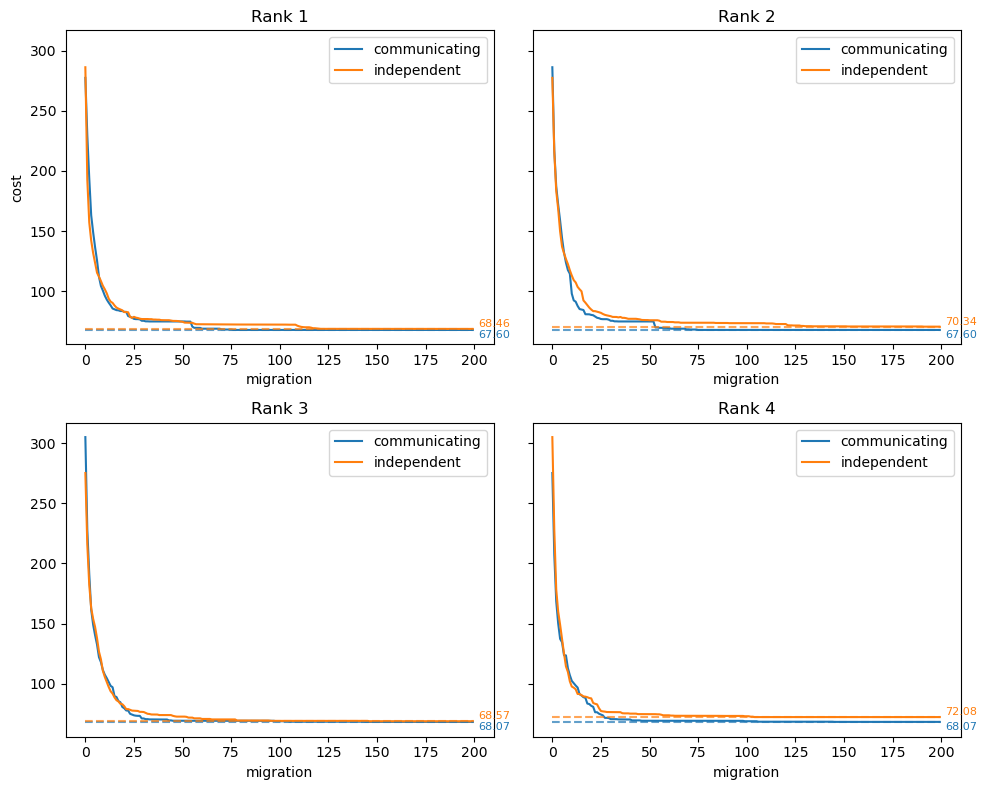

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

# Dati indipendenti
dfic = pd.read_csv('./OUTPUT/indep_costs.csv', sep='\t')

fig, axes = plt.subplots(2, 2, figsize=(10,8), sharey=True)
axes = axes.flatten()

costs = []
indep_costs =[]
for i in range(4):
    dfc = pd.read_csv(f'./OUTPUT/costs_{i}.csv', sep='\t')
    
    # linee principali
    line_comm, = axes[i].plot(dfc['gen'], dfc['cost'], label='communicating')
    line_ind,  = axes[i].plot(dfic['migr'], dfic[f'rank{i}'], label='independent')

    # colori coerenti
    color_comm = line_comm.get_color()
    color_ind = line_ind.get_color()

    # valori finali
    y_comm = dfc['cost'].iloc[-1]
    y_ind = dfic[f'rank{i}'].iloc[-1]
    costs.append(y_comm)
    indep_costs.append(y_ind)
    # linee orizzontali dashed
    axes[i].hlines(y_comm, 0, 200, linestyle='--', alpha=0.7, color=color_comm)
    axes[i].hlines(y_ind, 0, 200, linestyle='--', alpha=0.7, color=color_ind)

    # etichette numeriche vicino alle linee
    axes[i].text(202, y_comm, f'{y_comm:.2f}', va='top', fontsize=8, color=color_comm)
    axes[i].text(202, y_ind, f'{y_ind:.2f}', va='bottom', fontsize=8, color=color_ind)

    axes[i].set_xlabel('migration')
    axes[i].set_title(f'Rank {i+1}')
    axes[i].legend()

axes[0].set_ylabel('cost')
plt.tight_layout()
plt.show()



In [4]:
print('Best path costs for communicating processes:')
print(*costs)
print('Best path costs for independent processes:')
print(*indep_costs)

Best path costs for communicating processes:
67.5988 67.5988 68.0715 68.0715
Best path costs for independent processes:
68.4553 70.3378 68.5696 72.0818


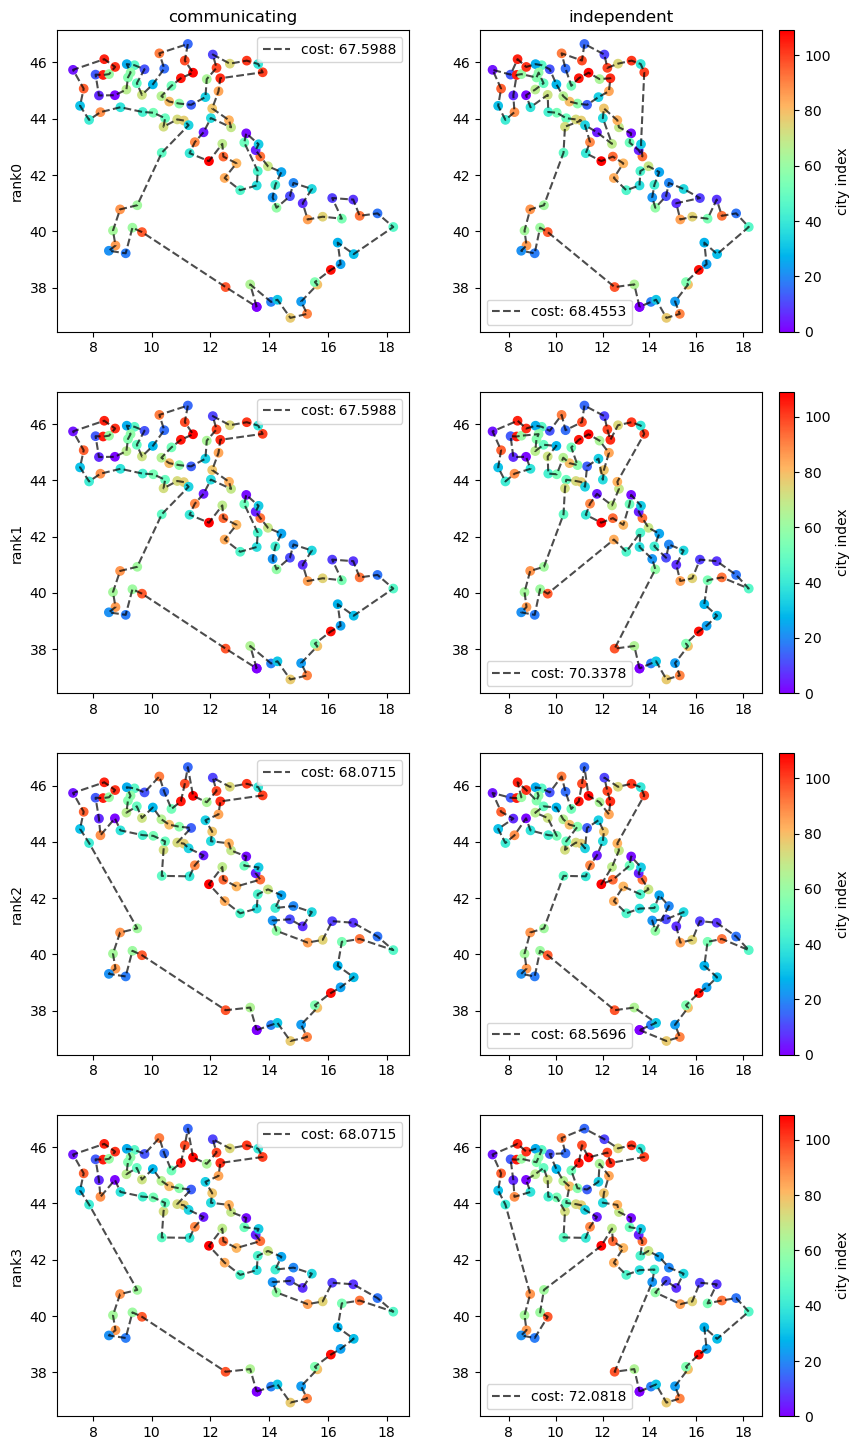

In [5]:
import matplotlib.pyplot as plt
import pandas as pd

fig,ax = plt.subplots(4,2,figsize=(10,18))



for i in range(4):
    df = pd.read_csv(f'./OUTPUT/best_path_{i}.csv',sep ='\t')
    
    df1 = pd.read_csv(f'./OUTPUT/indep_best_path_{i}.csv',sep ='\t')
    ax[i,0].plot(df['x'],df['y'],label=f'cost: {costs[i]}',linestyle ='dashed',color='black',alpha =0.7)
    ax[i,0].set_ylabel(f'rank{i}')

    ax[i,1].plot(df1['x'],df1['y'],label=f'cost: {indep_costs[i]}',linestyle ='dashed',color='black',alpha =0.7)
    ax[i,0].scatter(df['x'],df['y'],marker = 'o',c=df['index'],cmap = 'rainbow')
    sc = ax[i,1].scatter(df['x'],df['y'],marker = 'o',c=df['index'],cmap = 'rainbow')
    plt.colorbar(sc,label='city index')
    ax[i,0].legend()
    ax[i,1].legend()

ax[0,0].set_title('communicating')
ax[0,1].set_title('independent')

plt.show()


There is no deterministic way to establish whether the global minimum has been reached by the optimization algorithm. However, several observations suggest that the communicating-processes approach is the most effective:

- From the cost evolution plots, we observe that the communicating optimization converges to the final result (minimum) faster than the independent-processes case for all ranks.
- The best paths obtained at the end of the simulation exhibit lower costs in all communicating cases compared to the non-communicating ones.
- In the communicating case, ranks 0 and 1 converge to the same final result. By inspecting the corresponding path shown in Figure 2, this solution appears to be a strong candidate for the global minimum.
